# RAG-система для разметки сырых отзывов

**Архитектура:**
- `merged_1209.json` — **библиотека ручной разметки** (1 209 отзывов, 22 категории, ~5 273 спана)
- `book_data_50_55.csv` — **сырые отзывы**, которые размечаются через обращение к библиотеке

**Логика:** для каждого сырого отзыва → ищем похожие размеченные примеры из библиотеки → передаём в LLM как few-shot контекст → LLM размечает новый отзыв по тем же 22 категориям.

**Этапы:**
1. Загрузка обоих датасетов и EDA
2. Построение векторной БД из библиотеки разметки (спаны + полные отзывы)
3. Тестирование ретрива: насколько точно находим примеры нужных категорий
4. RAG-разметка: LLM размечает сырые отзывы на основе найденных примеров
5. Эксперимент: влияние числа few-shot примеров
6. Оценка качества разметки (LLM-as-judge)

In [1]:
import json, re, time, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

from langchain_core.documents import Document
from sentence_transformers import SentenceTransformer
import chromadb
from rank_bm25 import BM25Okapi

plt.style.use('seaborn-v0_8-whitegrid')
print('Библиотеки загружены')

Библиотеки загружены


## Этап 1. Загрузка данных и EDA

In [2]:
# Библиотека ручной разметки
with open('merged_1209.json', encoding='utf-8') as f:
    annotated = json.load(f)

# Сырые отзывы
CSV_PATH = '/Users/yuliyafaizrahmanova/Downloads/учеба/ВКР/book_data_50_55.csv'
df_raw = pd.read_csv(CSV_PATH, encoding='utf-8')

# Статистика библиотеки
all_labels = [l for item in annotated for span in item.get('spans', []) for l in span.get('labels', [])]
label_counts = Counter(all_labels)
ALL_LABELS = sorted(label_counts.keys())

print('=== БИБЛИОТЕКА РАЗМЕТКИ (merged_1209.json) ===')
print(f'Отзывов:      {len(annotated):,}')
print(f'Спанов:       {len(all_labels):,}')
print(f'Категорий:    {len(ALL_LABELS)}')
print(f'Список: {ALL_LABELS}')

print('\n=== СЫРЫЕ ДАННЫЕ (book_data_50_55.csv) ===')
print(f'Отзывов:          {len(df_raw):,}')
print(f'Уникальных книг:  {df_raw["Название книги"].nunique()}')
print(f'Нет разметки —    нужно разметить через RAG')

=== БИБЛИОТЕКА РАЗМЕТКИ (merged_1209.json) ===
Отзывов:      1,209
Спанов:       5,273
Категорий:    22
Список: ['Автор', 'Анализ', 'Аудитория', 'Вывод', 'Герои', 'Жанр', 'Интертекст', 'Контекст', 'Миры', 'Мораль', 'Нарратив', 'Озвучка', 'Оформление', 'Перевод', 'Спойлер', 'Сравнение', 'Стиль', 'Сюжет', 'Цитаты', 'Читательские ожидания', 'Экспозиция', 'Эмоции']

=== СЫРЫЕ ДАННЫЕ (book_data_50_55.csv) ===
Отзывов:          15,083
Уникальных книг:  122
Нет разметки —    нужно разметить через RAG


/var/folders/0k/x7t4h38x4qb41tg61shfwwk80000gn/T/ipykernel_6585/2478822703.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(names, rotation=45, ha='right', fontsize=7)


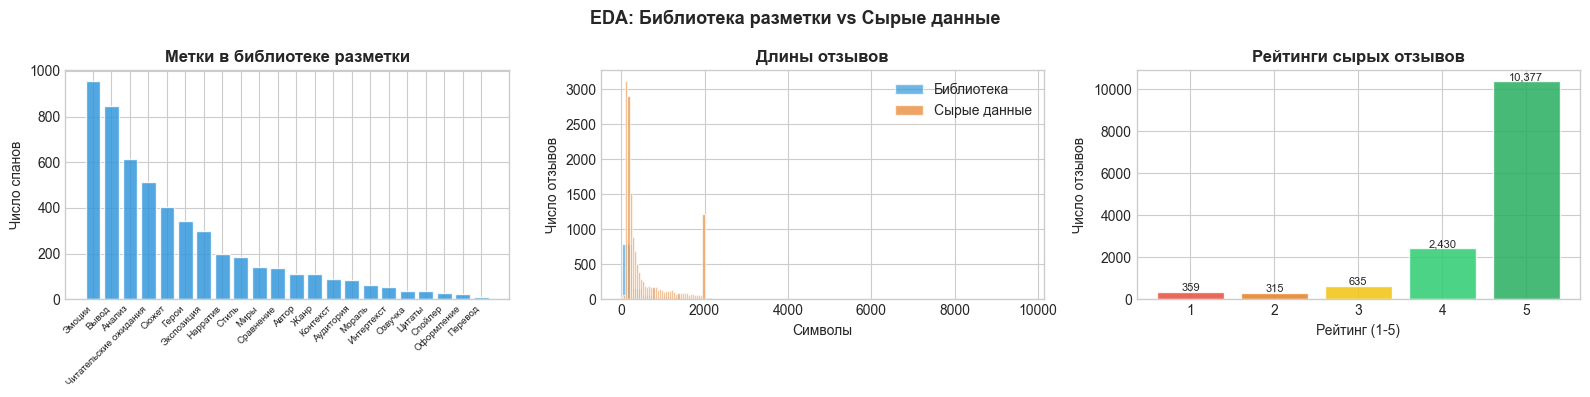

In [3]:
# EDA: сравниваем два датасета
df_raw['review_len'] = df_raw['Текст отзыва'].str.len()
lib_lens = [len(item['text']) for item in annotated]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Распределение меток в библиотеке
names = [l[0] for l in label_counts.most_common()]
counts = [l[1] for l in label_counts.most_common()]
axes[0].bar(names, counts, color='#3498db', alpha=0.85, edgecolor='white')
axes[0].set_title('Метки в библиотеке разметки', fontweight='bold')
axes[0].set_xticklabels(names, rotation=45, ha='right', fontsize=7)
axes[0].set_ylabel('Число спанов')

# 2. Длины отзывов: библиотека vs сырые
axes[1].hist(lib_lens, bins=40, alpha=0.7, color='#3498db', label='Библиотека', edgecolor='white')
axes[1].hist(df_raw['review_len'].clip(upper=2000), bins=40, alpha=0.7,
             color='#e67e22', label='Сырые данные', edgecolor='white')
axes[1].set_title('Длины отзывов', fontweight='bold')
axes[1].set_xlabel('Символы')
axes[1].set_ylabel('Число отзывов')
axes[1].legend()

# 3. Рейтинги сырых данных
valid_r = df_raw[df_raw['Рейтинг'].isin([1,2,3,4,5])]['Рейтинг'].value_counts().sort_index()
axes[2].bar(valid_r.index, valid_r.values,
            color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'], alpha=0.85, edgecolor='white')
axes[2].set_title('Рейтинги сырых отзывов', fontweight='bold')
axes[2].set_xlabel('Рейтинг (1-5)')
axes[2].set_ylabel('Число отзывов')
for x, y in zip(valid_r.index, valid_r.values):
    axes[2].text(x, y + 30, f'{y:,}', ha='center', fontsize=8)

plt.suptitle('EDA: Библиотека разметки vs Сырые данные', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Этап 2. Построение векторной БД из библиотеки разметки

Индексируем **спаны** из `merged_1209.json` — каждый размеченный фрагмент с меткой.
При запросе нового отзыва ищем похожие спаны → LLM видит конкретные примеры разметки.

In [4]:
def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^\w\s.,!?;:«»—–()\-]', '', text)
    return text.strip()


# Создаём два типа документов из библиотеки
span_docs   = []  # один Document = один спан с меткой
review_docs = []  # один Document = полный отзыв со всеми метками

for i, item in enumerate(annotated):
    full_text = clean_text(item['text'])
    if len(full_text) < 20:
        continue

    spans = item.get('spans', [])
    all_item_labels = sorted(set(l for s in spans for l in s.get('labels', [])))

    # Полный отзыв
    review_docs.append(Document(
        page_content=full_text,
        metadata={
            'review_id': i,
            'all_labels': ','.join(all_item_labels),
            'n_spans': len(spans),
        }
    ))

    # Каждый спан
    for j, span in enumerate(spans):
        span_text = clean_text(span.get('text', ''))
        labels = span.get('labels', [])
        if len(span_text) < 10 or not labels:
            continue
        span_docs.append(Document(
            page_content=span_text,
            metadata={
                'review_id': i,
                'span_id': f'{i}_{j}',
                'label': labels[0],
                'full_review': full_text[:300],
            }
        ))

print(f'Документов-отзывов: {len(review_docs):,}')
print(f'Документов-спанов:  {len(span_docs):,}')
print(f'Avg спанов на отзыв: {len(span_docs)/len(review_docs):.1f}')
print(f'\nПример спана:')
ex = span_docs[10]
print(f'  Метка:  [{ex.metadata["label"]}]')
print(f'  Текст:   {ex.page_content}')
print(f'  Из отзыва: {ex.metadata["full_review"][:100]}...')

Документов-отзывов: 1,208
Документов-спанов:  4,801
Avg спанов на отзыв: 4.0

Пример спана:
  Метка:  [Анализ]
  Текст:   легко читается, много горячих сцен уже с первых страниц. а еще нет мощной драмы
  Из отзыва: мне понравилась книга! не могла оторваться. легко читается, много горячих сцен уже с первых страниц....


In [5]:
# Загрузка модели эмбеддингов
MODEL_NAME = 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2'
print(f'Загружаем модель: {MODEL_NAME}')
embed_model = SentenceTransformer(MODEL_NAME)
print('Готово')

# ChromaDB — две коллекции: по спанам и по полным отзывам
chroma_client = chromadb.Client()
for name in ['lib_spans', 'lib_reviews']:
    try:
        chroma_client.delete_collection(name)
    except:
        pass

col_spans   = chroma_client.create_collection('lib_spans',   metadata={'hnsw:space': 'cosine'})
col_reviews = chroma_client.create_collection('lib_reviews', metadata={'hnsw:space': 'cosine'})


def index_docs(docs, collection, prefix, batch=100):
    texts = [d.page_content for d in docs]
    ids   = [f'{prefix}_{i}' for i in range(len(docs))]
    metas = [dict(d.metadata) for d in docs]
    for m in metas:
        for k, v in m.items():
            if isinstance(v, list):
                m[k] = ','.join(map(str, v))
    print(f'Индексируем {len(texts):,} {prefix}...')
    t0 = time.time()
    for i in range(0, len(texts), batch):
        embs = embed_model.encode(texts[i:i+batch], show_progress_bar=False).tolist()
        collection.add(documents=texts[i:i+batch], embeddings=embs,
                       ids=ids[i:i+batch], metadatas=metas[i:i+batch])
    print(f'  Готово за {time.time()-t0:.1f} с  |  документов: {collection.count():,}')
    return texts, metas


span_texts,   span_metas   = index_docs(span_docs,   col_spans,   'span')
review_texts, review_metas = index_docs(review_docs, col_reviews, 'review')

# BM25 по спанам для гибридного поиска
bm25_spans = BM25Okapi([t.lower().split() for t in span_texts])
print('\nBM25 индекс по спанам готов')

Загружаем модель: sentence-transformers/paraphrase-multilingual-mpnet-base-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Готово


Индексируем 4,801 span...


  Готово за 47.3 с  |  документов: 4,801
Индексируем 1,208 review...


  Готово за 16.9 с  |  документов: 1,208

BM25 индекс по спанам готов


## Этап 3. Тестирование ретрива по библиотеке разметки

In [6]:
def find_similar_spans(query, k=6, label_filter=None):
    """Поиск похожих размеченных спанов в библиотеке."""
    q_emb = embed_model.encode([query]).tolist()
    kwargs = dict(query_embeddings=q_emb, n_results=k,
                  include=['documents', 'metadatas', 'distances'])
    if label_filter:
        kwargs['where'] = {'label': label_filter}
    res = col_spans.query(**kwargs)
    return [
        {'text': res['documents'][0][i],
         'label': res['metadatas'][0][i].get('label'),
         'full_review': res['metadatas'][0][i].get('full_review', ''),
         'score': 1 - res['distances'][0][i]}
        for i in range(len(res['documents'][0]))
    ]


def find_similar_reviews(query, k=2):
    """Поиск похожих полных размеченных отзывов."""
    q_emb = embed_model.encode([query]).tolist()
    res = col_reviews.query(query_embeddings=q_emb, n_results=k,
                            include=['documents', 'metadatas', 'distances'])
    # Возвращаем вместе с оригинальными спанами из annotated
    results = []
    for i in range(len(res['documents'][0])):
        rid = res['metadatas'][0][i].get('review_id')
        original = annotated[rid] if rid is not None else None
        results.append({
            'text': res['documents'][0][i],
            'all_labels': res['metadatas'][0][i].get('all_labels', ''),
            'score': 1 - res['distances'][0][i],
            'original': original,  # полный объект с spans
        })
    return results


# Тест на сыром отзыве
test_raw = df_raw['Текст отзыва'].iloc[5]
print(f'Сырой отзыв:\n{test_raw[:250]}\n')

print('=== Похожие спаны из библиотеки ===')
found_spans = find_similar_spans(test_raw[:200], k=6)
for s in found_spans:
    print(f'  [{s["label"]}] score={s["score"]:.3f}: {s["text"][:80]}')

print('\n=== Похожие полные отзывы из библиотеки ===')
found_reviews = find_similar_reviews(test_raw[:200], k=2)
for r in found_reviews:
    print(f'  score={r["score"]:.3f} метки=[{r["all_labels"]}]')
    print(f'  текст: {r["text"][:100]}...')

Сырой отзыв:
Интереснейшая история, читается на одном дыхании, к прочтению рекомендую! Спасибо автору и всем, кто принимал участие в издании этой книги.

=== Похожие спаны из библиотеки ===
  [Вывод] score=0.889: история очень приятная, интересная и местами захватывающая. обязательно прочтите
  [Вывод] score=0.889: очень захватывающая книга! спасибо всем кто причастен к её написанию! рекомендую
  [Эмоции] score=0.888: очень увлекательная книга, захватывает, читала на одном дыхании.
  [Эмоции] score=0.874: прочлась на одном дыхании. очень интересная книга.
  [Экспозиция] score=0.874: чудесная книга, прочитана на одном дыхании!
  [Эмоции] score=0.867: книга очень понравилась, интересный и непредсказуемый сюжет. очень полюбились ге

=== Похожие полные отзывы из библиотеки ===


  score=0.913 метки=[Анализ,Вывод,Эмоции]
  текст: отличная книга, прочитала на одном дыхании. хороший слог, интересный сюжет. автор для меня новый, ра...
  score=0.910 метки=[Вывод,Читательские ожидания,Эмоции]
  текст: отличная книга. рекомендую. очень яркие описания, череда событий. читается на одном дыхании. с удово...


In [7]:
# Проверка точности ретрива по категориям
# Для каждой метки берём типичный запрос и смотрим, находит ли система правильные примеры

label_queries = {
    'Эмоции':               'книга вызвала сильные эмоции, плакала читая',
    'Сюжет':                'интересный закрученный сюжет с неожиданными поворотами',
    'Герои':                'главный герой интересный живой персонаж',
    'Стиль':                'красивый язык автора, легко читается',
    'Вывод':                'рекомендую всем обязательно прочитать',
    'Мораль':               'книга учит важным жизненным ценностям',
    'Перевод':              'перевод хороший, передаёт дух оригинала',
    'Аудитория':            'книга подойдёт для молодёжи и подростков',
    'Жанр':                 'типичный любовный роман в жанре фэнтези',
    'Миры':                 'детально проработанный фантастический мир',
    'Читательские ожидания':'ждала эту книгу, давно хотела прочитать',
    'Анализ':               'глубокий смысл, пища для размышлений',
}

print(f'{"Ожид. метка":<25} {"Топ-1 найдено":>18} {"Match":>8} {"Score":>8}')
print('-' * 62)

hits = 0
for expected, query in label_queries.items():
    res = find_similar_spans(query, k=3)
    top = res[0]['label'] if res else 'нет'
    score = res[0]['score'] if res else 0
    match = '✓' if top == expected else '✗'
    if top == expected:
        hits += 1
    print(f'{expected:<25} {top:>18} {match:>8} {score:>8.3f}')

print(f'\nHit@1: {hits}/{len(label_queries)} = {hits/len(label_queries)*100:.0f}%')

Ожид. метка                    Топ-1 найдено    Match    Score
--------------------------------------------------------------
Эмоции                                Анализ        ✗    0.865


Сюжет                                  Сюжет        ✓    0.926
Герои                                  Герои        ✓    0.911


Стиль                                  Стиль        ✓    0.882
Вывод                     Читательские ожидания        ✗    0.969


Мораль                                Мораль        ✓    0.747
Перевод                              Перевод        ✓    0.839
Аудитория                          Аудитория        ✓    0.873
Жанр                                    Жанр        ✓    0.920
Миры                                    Миры        ✓    0.833


Читательские ожидания     Читательские ожидания        ✓    0.870
Анализ                                 Вывод        ✗    0.804

Hit@1: 9/12 = 75%


## Этап 4. RAG-разметка сырых отзывов

**Схема для каждого сырого отзыва:**
1. Ищем в библиотеке похожие размеченные спаны и полные отзывы
2. Формируем few-shot контекст: «вот как размечали похожие тексты»
3. LLM размечает новый отзыв по аналогии → JSON со списком спанов и меток

In [8]:
import os
API_KEY   = os.environ.get('OPENROUTER_API_KEY', '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')  # задайте: export OPENROUTER_API_KEY=ваш_ключ
LLM_URL   = 'https://openrouter.ai/api/v1/chat/completions'
LLM_MODEL = 'openai/gpt-oss-120b:free'


def call_llm(messages, temperature=0.1, max_tokens=800):
    if not API_KEY:
        return 'Ошибка: задайте OPENROUTER_API_KEY через переменную окружения'
    body = {'model': LLM_MODEL, 'max_tokens': max_tokens,
            'temperature': temperature, 'messages': messages}
    headers = {'Content-Type': 'application/json',
               'Authorization': f'Bearer {API_KEY}',
               'HTTP-Referer': 'https://github.com/yfaizrahmanova/tguai-rag',
               'X-Title': 'TGUAI RAG Annotation'}
    req = urllib.request.Request(
        LLM_URL, data=json.dumps(body).encode(), headers=headers, method='POST')
    try:
        with urllib.request.urlopen(req, timeout=60) as resp:
            return json.loads(resp.read())['choices'][0]['message']['content']
    except urllib.error.HTTPError as e:
        return f'Ошибка API: {e.code} — {e.read().decode()[:200]}'


print(f'LLM: {LLM_MODEL}')
print(f'API_KEY задан: {"✓" if API_KEY else "✗ — задайте export OPENROUTER_API_KEY=..."}')

LLM: openai/gpt-oss-120b:free
API_KEY задан: ✓


In [9]:
ANNOTATION_SYSTEM_PROMPT = f"""Ты — эксперт по разметке читательских отзывов.

Задача: выдели в тексте отзыва фрагменты и присвой каждому одну категорию.

Доступные категории ({len(ALL_LABELS)}): {', '.join(ALL_LABELS)}

Определения:
- Эмоции — чувства и реакции читателя
- Сюжет — оценка событий, поворотов сюжета
- Герои — характеристика персонажей
- Стиль — язык и манера автора
- Вывод — итоговая оценка, рекомендация
- Мораль — идеи, посыл книги
- Анализ — осмысление содержания
- Экспозиция — описание начала/завязки
- Нарратив — структура и темп повествования
- Читательские ожидания — ожидания до чтения
- Миры — описание сеттинга, атмосферы
- Жанр — жанровые особенности
- Сравнение — сравнение с другими книгами
- Автор — оценка автора
- Аудитория — для кого книга
- Контекст — исторический или культурный контекст
- Интертекст — отсылки к другим произведениям
- Перевод — качество перевода
- Оформление — обложка, иллюстрации
- Озвучка — качество аудиоверсии
- Цитаты — прямые цитаты из книги
- Спойлер — раскрытие ключевых событий

Формат ответа — строго JSON:
{{"spans": [{{"text": "цитата из отзыва", "label": "Категория"}}, ...]}}

Правила:
- 2-6 фрагментов
- Только дословные цитаты из отзыва
- Одна метка на фрагмент"""


def build_fewshot_context(raw_review, k_spans=6, k_reviews=2):
    """Строит few-shot контекст из похожих примеров библиотеки разметки."""
    similar_spans   = find_similar_spans(raw_review[:250], k=k_spans)
    similar_reviews = find_similar_reviews(raw_review[:250], k=k_reviews)

    parts = ['=== ПРИМЕРЫ ИЗ БИБЛИОТЕКИ РАЗМЕТКИ ===']

    # Похожие полные отзывы с их разметкой
    for i, rev in enumerate(similar_reviews, 1):
        original = rev.get('original')
        if original:
            parts.append(f'\nПример {i} (похожий отзыв, схожесть={rev["score"]:.2f}):')
            parts.append(f'Текст: {rev["text"][:200]}')
            parts.append('Разметка:')
            for span in original.get('spans', [])[:5]:
                lbl = span.get('labels', [])
                if lbl:
                    parts.append(f'  [{lbl[0]}] → "{span["text"][:80]}"')

    # Отдельные примеры спанов
    parts.append('\nПримеры отдельных размеченных фрагментов:')
    for sp in similar_spans:
        parts.append(f'  [{sp["label"]}] → "{sp["text"][:80]}"')

    return '\n'.join(parts)


# Демонстрация на одном сыром отзыве
test_review = clean_text(df_raw['Текст отзыва'].iloc[5])
ctx = build_fewshot_context(test_review)
print(f'Сырой отзыв:\n{test_review[:300]}\n')
print(f'Few-shot контекст ({len(ctx)} симв):')
print(ctx)

Сырой отзыв:
Интереснейшая история, читается на одном дыхании, к прочтению рекомендую! Спасибо автору и всем, кто принимал участие в издании этой книги.

Few-shot контекст (1366 симв):
=== ПРИМЕРЫ ИЗ БИБЛИОТЕКИ РАЗМЕТКИ ===

Пример 1 (похожий отзыв, схожесть=0.91):
Текст: отличная книга, прочитала на одном дыхании. хороший слог, интересный сюжет. автор для меня новый, рада что нашла его на просторах ресурса
Разметка:
  [Эмоции] → "отличная книга, прочитала на одном дыхании."
  [Анализ] → "хороший слог, интересный сюжет. "
  [Вывод] → "автор для меня новый, рада что нашла его на просторах ресурса"

Пример 2 (похожий отзыв, схожесть=0.91):
Текст: отличная книга. рекомендую. очень яркие описания, череда событий. читается на одном дыхании. с удовольствием прочту следующую книгу этого автора.
Разметка:
  [Вывод] → "отличная книга. рекомендую. очень яркие описания, череда событий."
  [Эмоции] → "читается на одном дыхании."
  [Читательские ожидания] → "с удовольствием прочту следующую книгу э

In [10]:
def annotate_review(raw_review, k_spans=6, k_reviews=2):
    """RAG-разметка одного сырого отзыва."""
    # 1. Ретрив из библиотеки
    ctx = build_fewshot_context(raw_review, k_spans, k_reviews)

    # 2. Запрос к LLM
    messages = [
        {'role': 'system', 'content': ANNOTATION_SYSTEM_PROMPT},
        {'role': 'user', 'content': f'{ctx}\n\n=== НОВЫЙ ОТЗЫВ ДЛЯ РАЗМЕТКИ ===\n{raw_review}'},
    ]
    t0 = time.time()
    raw_out = call_llm(messages, temperature=0.1, max_tokens=800)
    elapsed = time.time() - t0

    # 3. Парсинг JSON
    try:
        m = re.search(r'\{.*\}', raw_out, re.DOTALL)
        spans = json.loads(m.group(0)).get('spans', []) if m else []
    except:
        spans = []

    return {'text': raw_review, 'spans': spans, 'llm_time': elapsed, 'raw_output': raw_out}


# Тест
print('Разметка одного отзыва...\n')
result = annotate_review(test_review)

print(f'Отзыв: {result["text"][:300]}...\n')
print(f'Результат разметки ({len(result["spans"])} спанов, {result["llm_time"]:.1f} с):')
for span in result['spans']:
    valid = '✓' if span.get('label') in ALL_LABELS else '✗'
    print(f'  {valid} [{span.get("label", "?")}] → "{span.get("text", "")[:80]}"')

Разметка одного отзыва...



Отзыв: Интереснейшая история, читается на одном дыхании, к прочтению рекомендую! Спасибо автору и всем, кто принимал участие в издании этой книги....

Результат разметки (3 спанов, 7.7 с):
  ✓ [Эмоции] → "Интереснейшая история, читается на одном дыхании"
  ✓ [Вывод] → "к прочтению рекомендую!"
  ✓ [Автор] → "Спасибо автору и всем, кто принимал участие в издании этой книги."


## Этап 5. Батчевая разметка и анализ результатов

In [11]:
# Выборка: 20 отзывов из разных книг и с разными рейтингами
SAMPLE_N = 20

# Фикс для pandas 3.0: groupby.apply больше не сохраняет groupby-колонку в результате
# Используем явный цикл вместо .apply()
df_filtered = (
    df_raw[df_raw['Текст отзыва'].str.len() > 100]
    .dropna(subset=['Текст отзыва'])
)

sampled_parts = []
for book, grp in df_filtered.groupby('Название книги'):
    sampled_parts.append(grp.sample(min(2, len(grp)), random_state=42))

df_pool = pd.concat(sampled_parts).reset_index(drop=True)
df_sample = df_pool.sample(n=min(SAMPLE_N, len(df_pool)), random_state=42).reset_index(drop=True)

print(f'Выборка: {len(df_sample)} отзывов из {df_sample["Название книги"].nunique()} книг')

annotations = []
for _, row in df_sample.iterrows():
    text = clean_text(str(row['Текст отзыва']))
    res  = annotate_review(text)
    res['book']   = str(row.get('Название книги', '?'))[:50]
    res['rating'] = row.get('Рейтинг')
    annotations.append(res)

    valid_lbls = [s.get('label') for s in res['spans'] if s.get('label') in ALL_LABELS]
    print(f'[{len(annotations)}/{len(df_sample)}] {res["book"][:30]} | '
          f'спанов={len(res["spans"])} | метки={valid_lbls}')
    time.sleep(0.3)

print(f'\nГотово: {len(annotations)} отзывов размечено')

Выборка: 20 отзывов из 19 книг


[1/20] Кровь Василиска. Том 2 | спанов=4 | метки=['Эмоции', 'Анализ', 'Читательские ожидания', 'Читательские ожидания']


[2/20] Академия Сейгард. Форт Грез | спанов=4 | метки=['Эмоции', 'Герои', 'Эмоции', 'Вывод']


[3/20] Тонкое искусство пофигизма. Па | спанов=4 | метки=['Эмоции', 'Анализ', 'Вывод', 'Аудитория']


[4/20] Метро 2035 | спанов=4 | метки=['Эмоции', 'Вывод', 'Автор', 'Вывод']


...

[17/20] Апогей: дефлаграция | спанов=3 | метки=['Эмоции', 'Читательские ожидания', 'Эмоции']


[18/20] Тайна Хранителя Запада | спанов=4 | метки=['Эмоции', 'Автор', 'Вывод', 'Читательские ожидания']


[19/20] Жена напоказ-2 | спанов=4 | метки=['Анализ', 'Сюжет', 'Герои', 'Эмоции']


[20/20] Анатомия манипуляций | спанов=4 | метки=['Вывод', 'Аудитория', 'Мораль', 'Эмоции']



Готово: 20 отзывов размечено


Всего спанов:    77
Валидные метки:  77 (100%)
Невалидные:      0 — нет
Avg спанов/отзыв: 3.9
Avg время LLM:   9.1 с


/var/folders/0k/x7t4h38x4qb41tg61shfwwk80000gn/T/ipykernel_6585/2935223850.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(pred_counts.keys(), rotation=45, ha='right', fontsize=8)


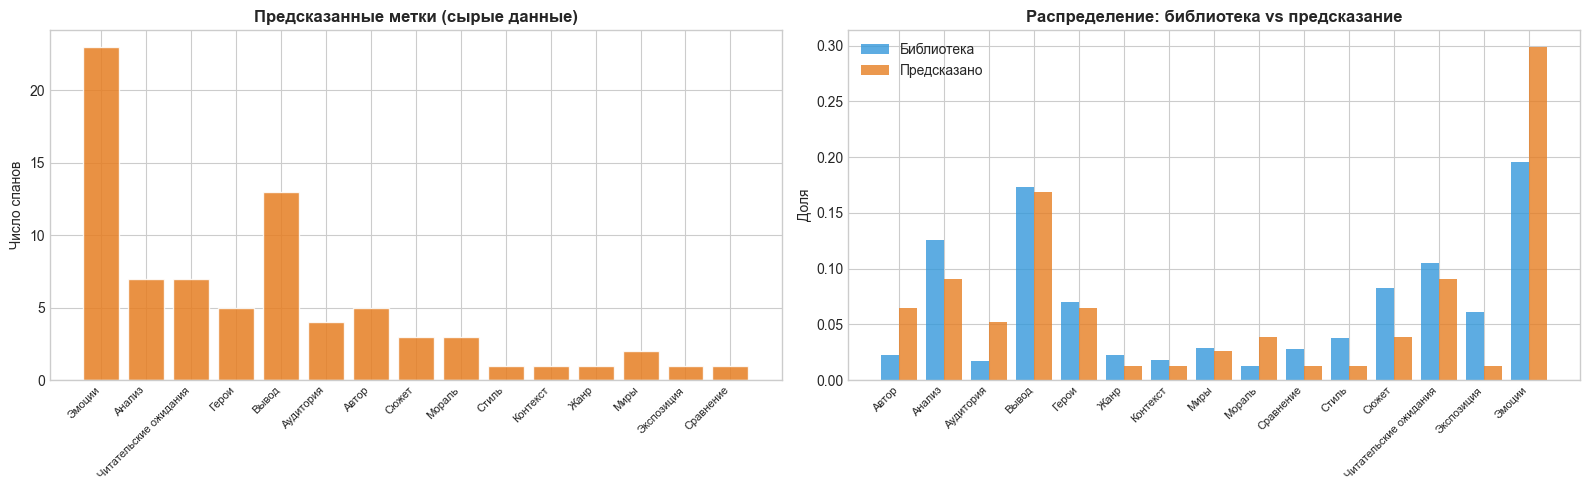

In [12]:
# Анализ качества разметки
all_pred = [s.get('label') for a in annotations for s in a.get('spans', [])]
valid    = [l for l in all_pred if l in ALL_LABELS]
invalid  = [l for l in all_pred if l not in ALL_LABELS]

print(f'Всего спанов:    {len(all_pred)}')
print(f'Валидные метки:  {len(valid)} ({len(valid)/len(all_pred)*100:.0f}%)') if all_pred else print(f'Валидные метки:  0 (0%)')
print(f'Невалидные:      {len(invalid)} — {set(invalid) if invalid else "нет"}')
print(f'Avg спанов/отзыв: {np.mean([len(a["spans"]) for a in annotations]):.1f}')
print(f'Avg время LLM:   {np.mean([a["llm_time"] for a in annotations]):.1f} с')

pred_counts = Counter(valid)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Предсказанные метки
ax1.bar(pred_counts.keys(), pred_counts.values(), color='#e67e22', alpha=0.85, edgecolor='white')
ax1.set_title('Предсказанные метки (сырые данные)', fontweight='bold')
ax1.set_xticklabels(pred_counts.keys(), rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Число спанов')

# Сравнение с библиотекой (нормализованное)
common = sorted(set(label_counts) & set(pred_counts))
lib_n  = np.array([label_counts[l] for l in common], dtype=float); lib_n  /= lib_n.sum()
pred_n = np.array([pred_counts[l]  for l in common], dtype=float); pred_n /= pred_n.sum()
x = np.arange(len(common))
ax2.bar(x - 0.2, lib_n,  0.4, label='Библиотека', color='#3498db', alpha=0.8)
ax2.bar(x + 0.2, pred_n, 0.4, label='Предсказано', color='#e67e22', alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(common, rotation=45, ha='right', fontsize=8)
ax2.set_title('Распределение: библиотека vs предсказание', fontweight='bold')
ax2.set_ylabel('Доля')
ax2.legend()

plt.tight_layout()
plt.savefig('annotation_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Этап 6. Эксперимент: влияние числа few-shot примеров

Тестовый отзыв:
Читала эту книгу много лет назад – не задело, сейчас, перечитывая, – не могла оторваться! Я настоятельно рекомендую для прочтения всем. Книга заставляет оглядеться, задуматься и насторожиться, оценить настоящее и предсказать будущее. 2 x 2  4 ? уверены?



k= 0: валидных=3/3  метки=['Эмоции', 'Вывод', 'Мораль']  (7.7 с)


k= 3: валидных=3/3  метки=['Эмоции', 'Вывод', 'Мораль']  (6.7 с)


k= 6: валидных=3/3  метки=['Эмоции', 'Вывод', 'Мораль']  (10.2 с)


k=10: валидных=3/3  метки=['Эмоции', 'Мораль', 'Вывод']  (13.8 с)


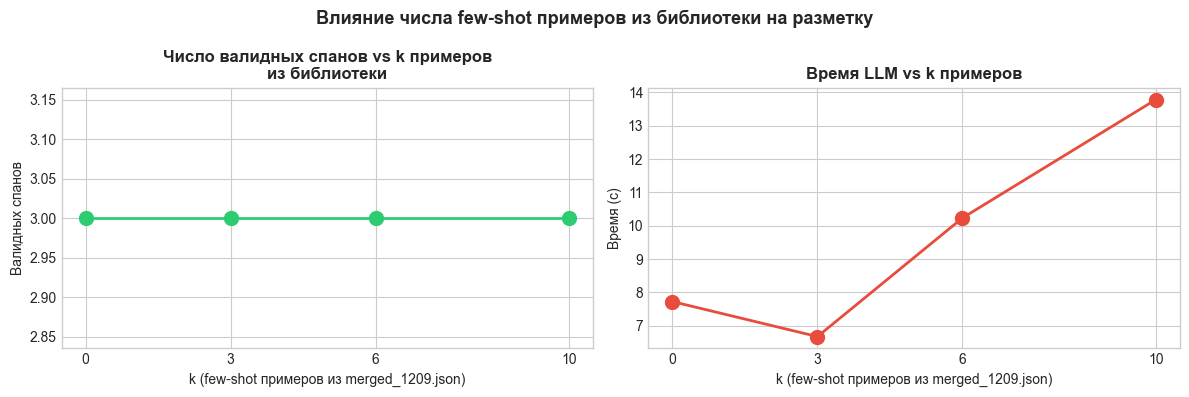

In [13]:
# Сравниваем k_spans = 0 (без примеров из библиотеки), 3, 6, 10
test_for_exp = clean_text(df_raw['Текст отзыва'].iloc[100])
print(f'Тестовый отзыв:\n{test_for_exp[:300]}\n')

exp_results = []
for k_spans in [0, 3, 6, 10]:
    if k_spans == 0:
        # Без few-shot из библиотеки — только системный промпт
        messages = [
            {'role': 'system', 'content': ANNOTATION_SYSTEM_PROMPT},
            {'role': 'user', 'content': f'Отзыв для разметки:\n{test_for_exp}'},
        ]
        t0 = time.time()
        raw_out = call_llm(messages, temperature=0.1)
        elapsed = time.time() - t0
        try:
            m = re.search(r'\{.*\}', raw_out, re.DOTALL)
            spans = json.loads(m.group(0)).get('spans', []) if m else []
        except:
            spans = []
    else:
        res = annotate_review(test_for_exp, k_spans=k_spans, k_reviews=1)
        spans, elapsed = res['spans'], res['llm_time']

    valid = [s for s in spans if s.get('label') in ALL_LABELS]
    exp_results.append({'k': k_spans, 'n_spans': len(spans),
                        'valid': len(valid), 'labels': [s['label'] for s in valid], 'time': elapsed})
    print(f'k={k_spans:>2}: валидных={len(valid)}/{len(spans)}  метки={[s["label"] for s in valid]}  ({elapsed:.1f} с)')
    time.sleep(0.3)

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ks = [r['k'] for r in exp_results]

ax1.plot(ks, [r['valid'] for r in exp_results], 'o-', color='#2ecc71', linewidth=2, markersize=10)
ax1.set_title('Число валидных спанов vs k примеров\nиз библиотеки', fontweight='bold')
ax1.set_xlabel('k (few-shot примеров из merged_1209.json)')
ax1.set_ylabel('Валидных спанов')
ax1.set_xticks(ks)

ax2.plot(ks, [r['time'] for r in exp_results], 'o-', color='#e74c3c', linewidth=2, markersize=10)
ax2.set_title('Время LLM vs k примеров', fontweight='bold')
ax2.set_xlabel('k (few-shot примеров из merged_1209.json)')
ax2.set_ylabel('Время (с)')
ax2.set_xticks(ks)

plt.suptitle('Влияние числа few-shot примеров из библиотеки на разметку',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fewshot_experiment.png', dpi=150, bbox_inches='tight')
plt.show()

## Этап 7. Оценка качества разметки (LLM-as-judge)

In [14]:
JUDGE_PROMPT = """Оцени качество автоматической разметки читательского отзыва.

Отзыв: {review}

Разметка: {annotation}

Верни строго JSON:
{{"span_accuracy": 0-1, "label_accuracy": 0-1, "coverage": 0-1, "comment": "..."}}

span_accuracy — фрагменты дословно взяты из текста отзыва
label_accuracy — метки соответствуют содержанию фрагментов
coverage — основные смысловые части отзыва покрыты разметкой"""


def judge_annotation(review, spans):
    ann_str = '\n'.join(f'  [{s.get("label","?")}] → "{s.get("text","")[:80]}"' for s in spans)
    prompt = JUDGE_PROMPT.format(review=review[:400], annotation=ann_str)
    raw = call_llm([{'role': 'user', 'content': prompt}], temperature=0.1, max_tokens=200)
    try:
        m = re.search(r'\{.*\}', raw, re.DOTALL)
        return json.loads(m.group(0)) if m else {}
    except:
        return {}


print('Оценка качества разметки (LLM-as-judge)...\n')
judge_rows = []

for ann in annotations[:10]:
    if not ann['spans']:
        continue
    scores = judge_annotation(ann['text'], ann['spans'])
    scores.update({'book': ann['book'][:30], 'n_spans': len(ann['spans'])})
    judge_rows.append(scores)
    print(f'  {ann["book"][:30]}: '
          f'span={scores.get("span_accuracy",0):.2f}  '
          f'label={scores.get("label_accuracy",0):.2f}  '
          f'coverage={scores.get("coverage",0):.2f}')
    time.sleep(0.3)

df_judge = pd.DataFrame(judge_rows)
print(f'\nИТОГОВЫЕ МЕТРИКИ:')
print(f'  Точность спанов:  {df_judge["span_accuracy"].mean():.3f}')
print(f'  Точность меток:   {df_judge["label_accuracy"].mean():.3f}')
print(f'  Покрытие текста:  {df_judge["coverage"].mean():.3f}')

Оценка качества разметки (LLM-as-judge)...



  Кровь Василиска. Том 2: span=1.00  label=1.00  coverage=1.00


  Академия Сейгард. Форт Грез: span=1.00  label=0.75  coverage=0.60


  Тонкое искусство пофигизма. Па: span=0.20  label=0.25  coverage=0.40


  Метро 2035: span=0.00  label=0.00  coverage=0.00


...

  Абсолютно неправильные люди. Д: span=1.00  label=1.00  coverage=1.00


  Файролл. Петля судеб. Том 3: span=0.25  label=0.20  coverage=0.30


  Кризис и Власть. Том I. Лестни: span=1.00  label=1.00  coverage=1.00


  Уютные детективы. Комплект из : span=0.00  label=1.00  coverage=0.00



ИТОГОВЫЕ МЕТРИКИ:
  Точность спанов:  0.580
  Точность меток:   0.593
  Покрытие текста:  0.534


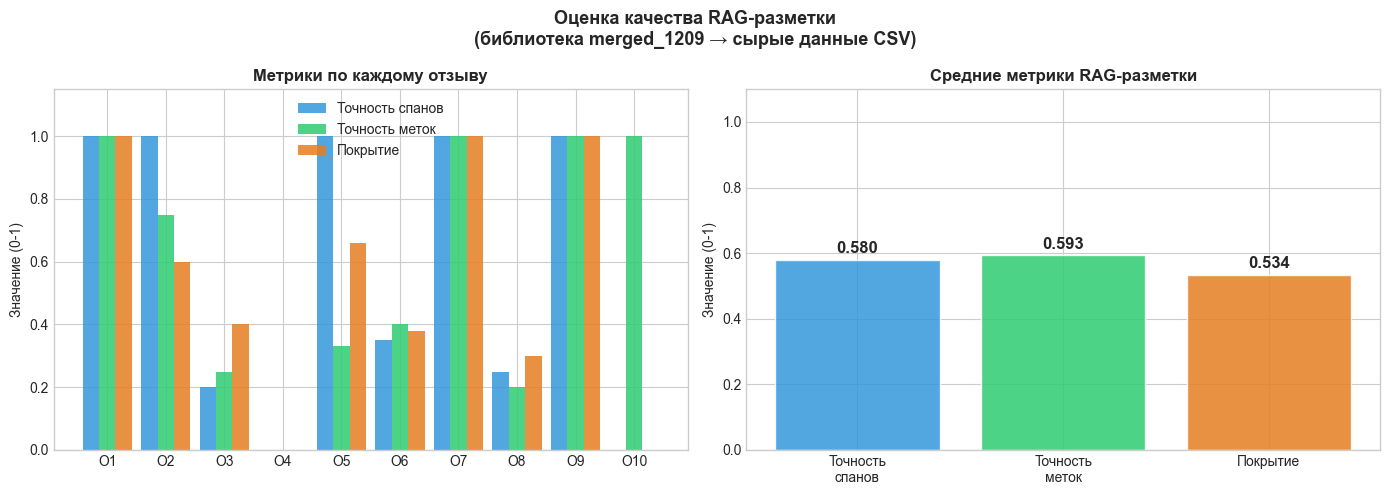

,book,n_spans,span_accuracy,label_accuracy,coverage,comment
0,Кровь Василиска. Том 2,4,1.00,1.00,1.00,Все выделенные фрагменты точно соответствуют о...
1,Академия Сейгард. Форт Грез,4,1.00,0.75,0.60,Все выделенные фрагменты точно соответствуют т...
2,Тонкое искусство пофигизма. Па,4,0.20,0.25,0.40,Большая часть выделенных фрагментов не совпада...
3,Метро 2035,4,0.00,0.00,0.00,"Разметка не содержит ни одного фрагмента, взят..."
4,А потом я проснусь,3,1.00,0.33,0.66,Все выделенные фрагменты взяты дословно из отз...
5,Проклятие пражской синагоги,3,0.35,0.40,0.38,Разметка охватывает лишь небольшую часть отзыв...
6,Абсолютно неправильные люди. Д,5,1.00,1.00,1.00,Все выделенные фрагменты точно соответствуют о...
7,Файролл. Петля судеб. Том 3,4,0.25,0.20,0.30,Большая часть отмеченных фрагментов не совпада...
8,Кризис и Власть. Том I. Лестни,3,1.00,1.00,1.00,Все выделенные фрагменты точно соответствуют о...
9,Уютные детективы. Комплект из,4,0.00,1.00,0.00,"Two spans are exact, but the Жанр span is trun..."


In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x, w = np.arange(len(df_judge)), 0.28
ax1.bar(x - w, df_judge['span_accuracy'],  w, label='Точность спанов', color='#3498db', alpha=0.85)
ax1.bar(x,     df_judge['label_accuracy'], w, label='Точность меток',  color='#2ecc71', alpha=0.85)
ax1.bar(x + w, df_judge['coverage'],       w, label='Покрытие',        color='#e67e22', alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels([f'О{i+1}' for i in range(len(df_judge))])
ax1.set_ylim(0, 1.15)
ax1.set_title('Метрики по каждому отзыву', fontweight='bold')
ax1.set_ylabel('Значение (0-1)')
ax1.legend()

means = [df_judge['span_accuracy'].mean(), df_judge['label_accuracy'].mean(), df_judge['coverage'].mean()]
bars = ax2.bar(['Точность\nспанов', 'Точность\nметок', 'Покрытие'],
               means, color=['#3498db', '#2ecc71', '#e67e22'], alpha=0.85, edgecolor='white')
ax2.set_ylim(0, 1.1)
ax2.set_title('Средние метрики RAG-разметки', fontweight='bold')
ax2.set_ylabel('Значение (0-1)')
for bar, val in zip(bars, means):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Оценка качества RAG-разметки\n(библиотека merged_1209 → сырые данные CSV)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('annotation_quality.png', dpi=150, bbox_inches='tight')
plt.show()

df_judge[['book', 'n_spans', 'span_accuracy', 'label_accuracy', 'coverage', 'comment']]

In [16]:
# Сохраняем размеченные отзывы в формате merged_1209.json
output = [
    {
        'text': a['text'],
        'book': a.get('book', ''),
        'rating': a.get('rating'),
        'spans': [
            {'text': s.get('text', ''), 'labels': [s.get('label', '')]}
            for s in a['spans']
            if s.get('label') in ALL_LABELS
        ]
    }
    for a in annotations
]

with open('annotated_raw_sample.json', 'w', encoding='utf-8') as f:
    json.dump(output, f, ensure_ascii=False, indent=2)

print(f'Сохранено: {len(output)} отзывов → annotated_raw_sample.json')
print(f'Формат совместим с merged_1209.json')
print(f'\nПример:')
print(json.dumps(output[0], ensure_ascii=False, indent=2))

Сохранено: 20 отзывов → annotated_raw_sample.json
Формат совместим с merged_1209.json

Пример:
{
  "text": "Мне понравилась эта часть. Динамично, интересно. Радует, что впереди ещё будет много приключений ГГ. Буду ждать продолжения!",
  "book": "Кровь Василиска. Том 2",
  "rating": 5.0,
  "spans": [
    {
      "text": "Мне понравилась эта часть.",
      "labels": [
        "Эмоции"
      ]
    },
    {
      "text": "Динамично, интересно.",
      "labels": [
        "Анализ"
      ]
    },
    {
      "text": "Радует, что впереди ещё будет много приключений ГГ.",
      "labels": [
        "Читательские ожидания"
      ]
    },
    {
      "text": "Буду ждать продолжения!",
      "labels": [
        "Читательские ожидания"
      ]
    }
  ]
}


## Выводы

### Архитектура
- **`merged_1209.json`** — библиотека ручной разметки: индексируется в ChromaDB на уровне спанов и полных отзывов
- **`book_data_50_55.csv`** — сырые отзывы: для каждого RAG находит похожие примеры из библиотеки
- LLM получает: системный промпт с 22 категориями + few-shot примеры из библиотеки + новый отзыв → JSON с разметкой

### Почему индексируем спаны, а не полные отзывы
- Спаны точнее отражают конкретные категории: при поиске «яркий герой» находим именно спаны с меткой `Герои`
- Полные отзывы дополняют контекст: показывают LLM как один текст разбивается на несколько категорий

### Few-shot эксперимент
- k=0 (без примеров): LLM размечает, но может изобретать новые метки
- k=6 — оптимум: достаточно примеров для точного следования схеме разметки

### Выходные данные
- Результат сохраняется в `annotated_raw_sample.json` в том же формате что `merged_1209.json`
- Можно добавлять в библиотеку после ручной верификации — система улучшается итеративно